In [1]:
from erebus.individual_fit_results import IndividualFitResults
from erebus.joint_fit_results import JointFitResults
import numpy as np
import os
from uncertainties import ufloat
import yaml
import matplotlib.pyplot as plt
import matplotlib
from matplotlib import cm
from matplotlib import colors as colours
from scipy.stats import norm
from erebus.utility.utils import bin_data
from erebus.utility.utils import get_eclipse_duration
from erebus.photometry_data import PhotometryData
import numpy as np
import matplotlib.pyplot as plt
from glob import glob
from astropy.time import Time
from erebus.systematics.frame_normalized_pca import perform_fn_pca_on_aperture
from scipy.optimize import curve_fit
from uncertainties import ufloat

plt.rcParams.update({
	'font.family': 'serif',
    'font.serif': ['cmr10'],
    'mathtext.fontset': 'cm',
    'axes.formatter.use_mathtext': True,    
	'font.size': 9,
    'axes.labelsize': 9,
    'axes.titlesize': 9,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'legend.fontsize': 8,
    'lines.linewidth': 1.0,
    'figure.dpi': 300,
})

single_column = (3.5, 2.625)
double_column = (7, 5.25)

def get_eclipse_duration_from_res(visit):
	return get_eclipse_duration(
		visit.results['inc'].nominal_value,
		visit.results['a_rstar'].nominal_value,
		visit.results['rp_rstar'].nominal_value,
		visit.results['p'].nominal_value
	) * 24

In [3]:
visit1 = JointFitResults.load(glob("FNPCA leave one out/Visit 1/*joint_fit.h5")[0])
visit2 = JointFitResults.load(glob("FNPCA leave one out/Visit 2/*joint_fit.h5")[0])
visit3 = JointFitResults.load(glob("FNPCA leave one out/Visit 3/*joint_fit.h5")[0])
visit4 = JointFitResults.load(glob("FNPCA leave one out/Visit 4/*joint_fit.h5")[0])

2026-05-20 16:34:59,303 - stpipe - WARNING - /home/nicho/.local/lib/python3.11/site-packages/uncertainties/core.py:1024: UserWarning: Using UFloat objects with std_dev==0 may give unexpected results.
  warn("Using UFloat objects with std_dev==0 may give unexpected results.")



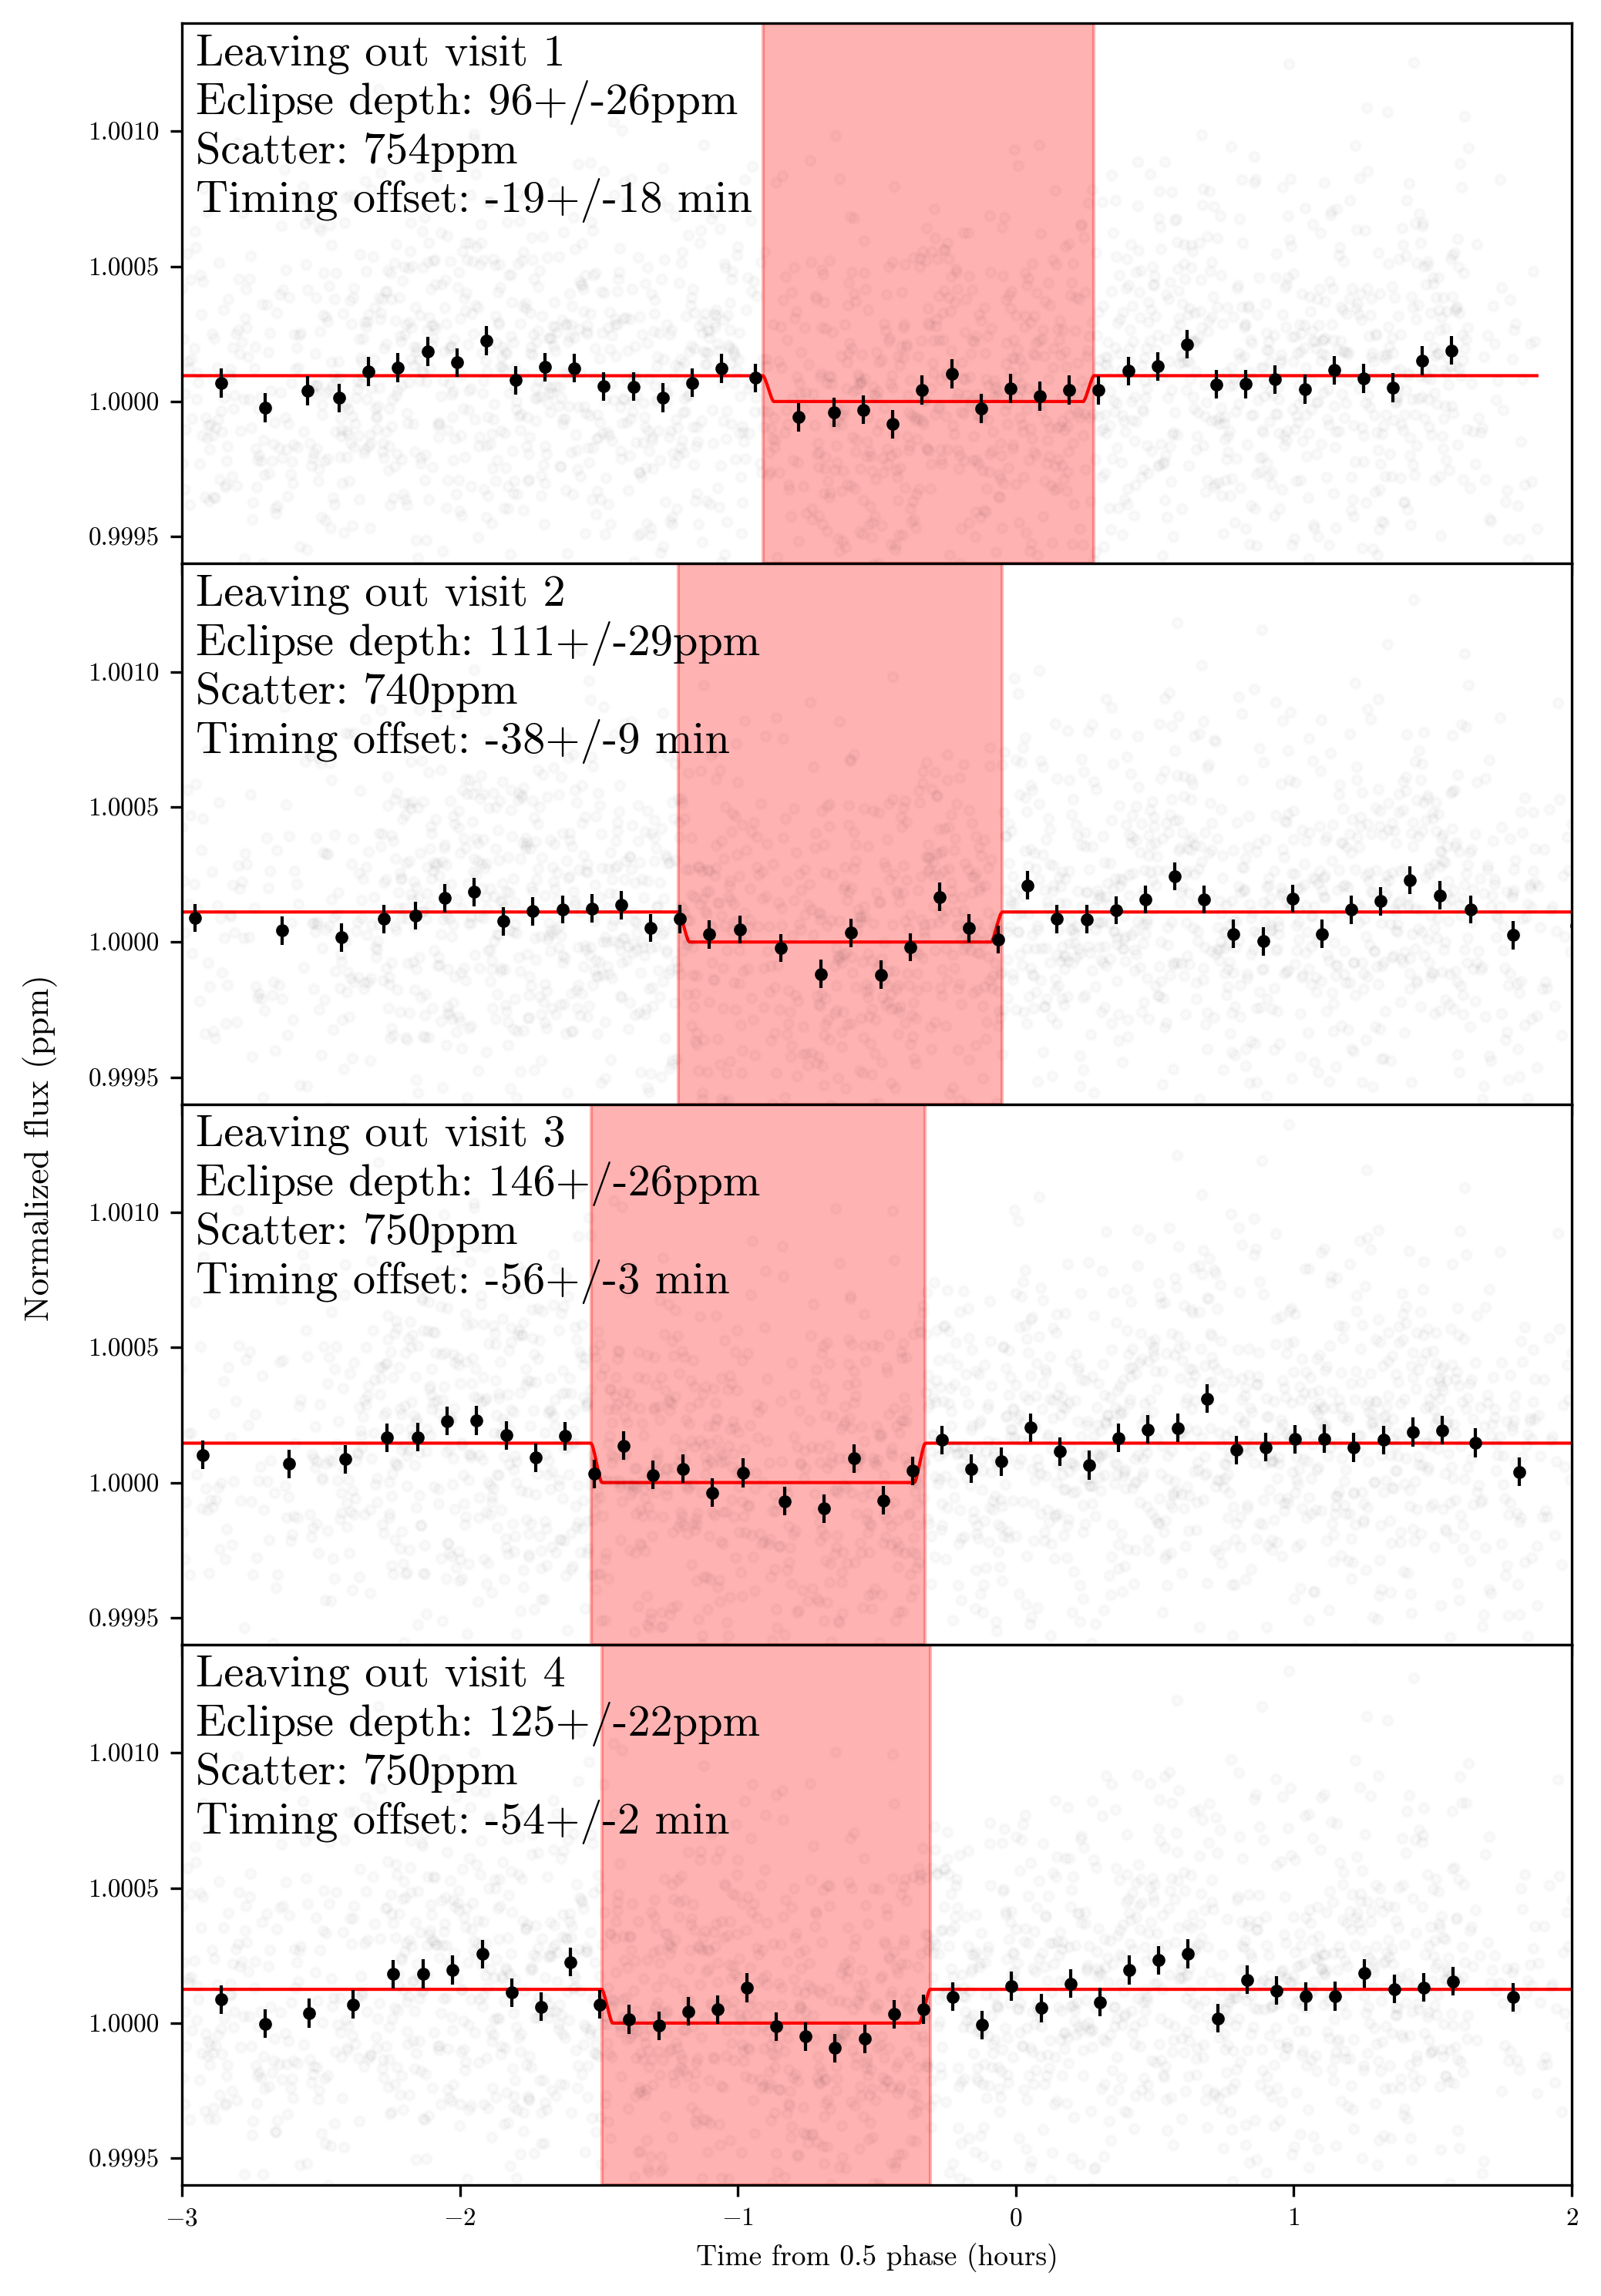

In [4]:
fig, axs = plt.subplots(4, 1, figsize=(7, 10), sharey='col', sharex='col')

def plot_individual(visit, i, visit_index):	
	ax = axs[i]
	
	yerr = visit.results['y_err'].nominal_value
	fp = visit.results['fp'].nominal_value
	fp_err = visit.results['fp'].std_dev

	duration = get_eclipse_duration_from_res(visit)

	# Joint fit
	bin_size = 200//4
	time = visit.time_per_visit.flatten()
	flux = visit.detrended_flux_per_visit.flatten()
	flux = flux[np.argsort(time)]
	time = np.sort(time)
	time = time[~np.isnan(time)]
	flux = flux[~np.isnan(flux)]
	
	model_time = visit.time_per_visit.flatten()
	model = visit.model_flux_per_visit.flatten()
	model = model[np.argsort(model_time)]
	model_time = np.sort(model_time)
	model = model[~np.isnan(model)]
	model_time = model_time[~np.isnan(model_time)]

	#s = np.where((model_time > -1.7) & (model_time < 2))
	#model_time = model_time[s]
	#model = model[s]


	binned_time, _ = bin_data(time, bin_size)
	binned_flux, _ = bin_data(flux, bin_size)

	ax.plot(model_time, model, color='red')

	t_sec = visit.results['t_sec_offset'].nominal_value * 24
	
	ax.plot(time, flux, marker='.', linestyle='', alpha=0.02, color='black')
	ax.errorbar(binned_time, binned_flux, yerr=yerr / np.sqrt(bin_size), linestyle='', marker='.', color='black')
	ax.axvspan(t_sec - duration / 2.0, t_sec + duration / 2.0, color='red', alpha=0.3)

	display_text = f"Leaving out visit {visit_index}"
	display_text += f"\nEclipse depth: {fp*1e6:.0f}+/-{fp_err*1e6:.0f}ppm"
	bin_size = 1 if visit_index >= 0 else 4
	display_text += f"\nScatter: {visit.results['y_err'].nominal_value*1e6*np.sqrt(bin_size)*2:0.0f}ppm"
	t_sec_offset = visit.results['t_sec_offset'] * 24 * 60
	display_text += f"\nTiming offset: {t_sec_offset.nominal_value:.0f}+/-{t_sec_offset.std_dev:.0f} min"
	ax.text(0.01, 0.98, display_text, horizontalalignment='left', verticalalignment='top', transform=ax.transAxes, fontsize=14)

plot_individual(visit1, 0, 1)
plot_individual(visit2, 1, 2)
plot_individual(visit3, 2, 3)
plot_individual(visit4, 3, 4)

for ax in axs:
	ax.set_ylim([0.9994, 1.0014])
	ax.set_yticks([0.9995, 1, 1.0005, 1.001])
	ax.set_yticklabels([0.9995, '1.0000', 1.0005, '1.0010'])
	#ax.set_xlim([-3, 2])

fig.supylabel("Normalized flux (ppm)")
axs[-1].set_xlabel("Time from 0.5 phase (hours)")
plt.xlim([-3, 2])

plt.tight_layout()
plt.subplots_adjust(hspace=0, wspace=0.2)
plt.savefig("figures/leave_one_out.png", bbox_inches='tight')
plt.savefig("figures/leave_one_out.pdf", bbox_inches='tight')
plt.show()